# Survival Analysis — Time-to-Attrition

**Kaplan-Meier** curves (does overtime shorten how long
people stay?) and a **Cox model** (which factors speed up or slow down
attrition, holding others constant)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv", encoding="utf-8")


In [2]:
df["duration"] = df["YearsAtCompany"]
df["event"] = (df["Attrition"] == "Yes").astype(int)  # 1 = left, 0 = still employed 

print(df[["duration", "event"]].describe())

          duration        event
count  1470.000000  1470.000000
mean      7.008163     0.161224
std       6.126525     0.367863
min       0.000000     0.000000
25%       3.000000     0.000000
50%       5.000000     0.000000
75%       9.000000     0.000000
max      40.000000     1.000000


## Kaplan-Meier: overall retention curve

Probability of still being employed, by years of tenure.


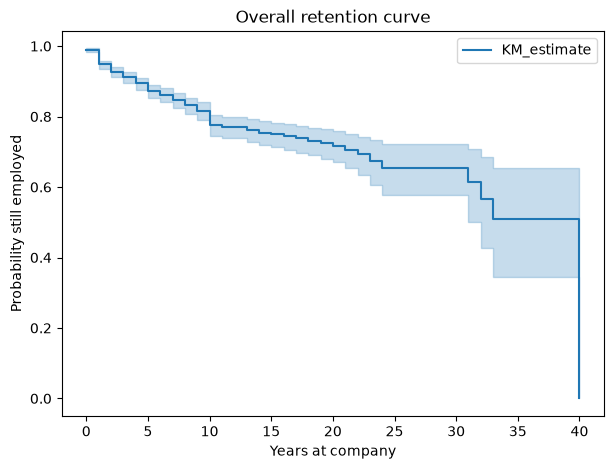

Median survival time: 40.0


In [3]:
kmf = KaplanMeierFitter()
kmf.fit(df["duration"], event_observed=df["event"])

plt.figure(figsize=(7, 5))
kmf.plot_survival_function()
plt.title("Overall retention curve")
plt.xlabel("Years at company")
plt.ylabel("Probability still employed")
plt.show()

print(f"Median survival time: {kmf.median_survival_time_}")


## Kaplan-Meier: OverTime vs not

The classification notebook's strongest finding was OverTime's effect on
attrition. Check whether it also shows up as a *faster* time-to-leaving,
not just a higher eventual rate.


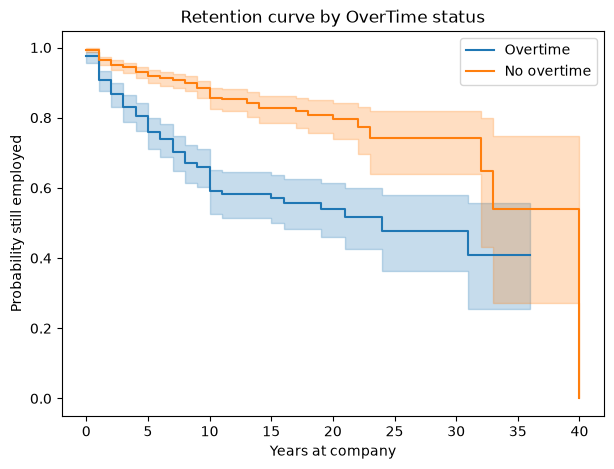

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

for value, label in [("Yes", "Overtime"), ("No", "No overtime")]:
    mask = df["OverTime"] == value
    kmf_group = KaplanMeierFitter()
    kmf_group.fit(df.loc[mask, "duration"], event_observed=df.loc[mask, "event"], label=label)
    kmf_group.plot_survival_function(ax=ax)

plt.title("Retention curve by OverTime status")
plt.xlabel("Years at company")
plt.ylabel("Probability still employed")
plt.show()


In [5]:
# Log-rank test: is the difference between the two curves statistically real,
# or could it plausibly be chance?
mask = df["OverTime"] == "Yes"
result = logrank_test(
    df.loc[mask, "duration"], df.loc[~mask, "duration"],
    event_observed_A=df.loc[mask, "event"], event_observed_B=df.loc[~mask, "event"],
)
print(f"Log-rank test p-value: {result.p_value:.4f}")


Log-rank test p-value: 0.0000


## Cox Proportional Hazards model

Which factors speed up or slow down attrition, holding the others constant.
Kept to the handful of features the earlier notebooks flagged as meaningful —
`OverTime`, `MonthlyIncome`, `JobSatisfaction`, `DistanceFromHome`


In [9]:
cox_df = df[["duration", "event", "OverTime", "MonthlyIncome", "JobSatisfaction", "DistanceFromHome"]].copy()
cox_df["OverTime"] = (cox_df["OverTime"] == "Yes").astype(int)

cph = CoxPHFitter()
cph.fit(cox_df, duration_col="duration", event_col="event")
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 1470 total observations, 1233 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1470
number of events observed = 237
   partial log-likelihood = -1453.99
         time fit was run = 2026-08-09 06:58:19 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
OverTime          1.16      3.19      0.13            0.90            1.41                2.47                4.12
MonthlyIncome    -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
JobSatisfaction  -0.24      0.79      0.06           -0.35           -0.12                0.70                0.88
DistanceFromHome  0.02      1.02      0.01            0.00            0.03                1.00                1.03

                  cmp to     z      p  -log2(p)
covariate                                      
OverTime            0.00  8.86 <0.005     60.13
MonthlyIncome       0.00 -9.59 <0.005     69.98
JobSatisfaction     0.00 -4.07 <0.005     14.37
DistanceFromHome    0.00  2.25   0.02      5.35
---
Concordance = 0.80
Partial AIC = 2915.98
log-likelihood ratio test = 240.26 on 4 df
-log2(p) of ll-ratio test = 166.39

## Reading the hazard ratios

`exp(coef)` above 1 means the factor speeds up attrition; below 1 means it
slows it down. E.g. an `OverTime` hazard ratio of 2.0 would mean overtime
workers leave at roughly twice the rate, at any given point in time, holding
income/satisfaction/distance constant.


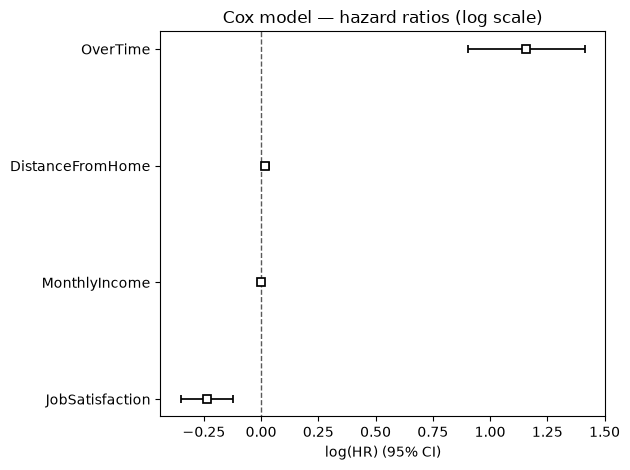

Concordance index (model fit, 0.5=random, 1.0=perfect): 0.797


In [10]:
cph.plot()
plt.title("Cox model — hazard ratios (log scale)")
plt.tight_layout()
plt.show()

print(f"Concordance index (model fit, 0.5=random, 1.0=perfect): {cph.concordance_index_:.3f}")


## Notes

- Duration = `YearsAtCompany`; event = `Attrition`. Employees who haven't left are censored at their current tenure — standard approach for cross-sectional HR data without exact hire/leave dates.
- Log-rank test checks whether the OverTime KM curves are meaningfully different, not just visually different.
- Cox model limited to 4 features already flagged as meaningful by the earlier EDA/classification work".
- Concordance index is the survival-analysis equivalent of AUC — how well the model ranks who leaves sooner vs later.

